# Automatic laser lock — scan → error sweep → lock point → PID

Notebook is the test UI. Hardware lives in `laserlock/` so a later headless script can import the same API.

### Sequence

1. Connect and park OUT1 at 0 V.
2. **Coarse scan:** jump to start, 1 s ramp, sit at 0 V.
3. Find the three sub-Doppler peaks (left to right). Repeat if the triplet is missing.
4. **Error sweep:** park uphill of the tallest line, dither, walk downhill and **record** iq0 vs voltage.
5. **Lock point:** mid-height between the min and max of the first S-curve from the high-V end (Linien simple autolock). DC-park, close I-only.



In [12]:
# ============================================================
# 1. IMPORTS AND USER CONFIGURATION
# ============================================================

import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from laserlock import (
    LaserDrive,
    configure_dither,
    connect,
    diagnose_hold_points,
    disengage_lock,
    engage_i_lock,
    park_at_lock_point,
    record_dithered_sweep,
    silence_feedback,
)
from laserlock.lockpoint import lock_point_from_trace
from laserlock.peaks import analyze_spectrum, plot_peak_analysis


HOSTNAME = "rp-f0c970.local"
PYRPL_CONFIG = "my_config"
RELOAD_FPGA = True

AUTO_LOCK = True
IDLE_V = 0.0
LOCK_MIN_V = -1.0
LOCK_MAX_V = +1.0


In [13]:
# ============================================================
# 2. CONNECT TO RED PITAYA
# ============================================================

p, rp = connect(
    hostname=HOSTNAME,
    config=PYRPL_CONFIG,
    reloadfpga=RELOAD_FPGA,
    gui=False,
)

drive = LaserDrive(rp, idle_v=IDLE_V)
drive.enable_idle()

print("ASG waveform memory:", drive.asg.data_length, "points")
print("Scope samples:", drive.scope.data_length)


INFO:pyrpl:All your PyRPL settings will be saved to the config file
    /Users/brandon/pyrpl_user_dir/config/my_config.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe my_config" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('my_config')
in a python terminal.


Connecting to Red Pitaya...
  hostname:    rp-f0c970.local
  config:      my_config
  user_dir:    /Users/brandon/Documents/Python Scripts/Grok Laser/pyrpl_data
  reloadfpga:  True


INFO:pyrpl.redpitaya:Found FPGA binfile at: /Users/brandon/Documents/Python Scripts/Grok Laser/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.bin
INFO:pyrpl.redpitaya:Found DTBO file at: /Users/brandon/Documents/Python Scripts/Grok Laser/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.dtbo
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname rp-f0c970.local.


Connected. Analog outputs are disconnected until the laser drive enables OUT1.
OUT1 enabled, parked at +0.0000 V.
ASG waveform memory: 16384 points
Scope samples: 16384


## Coarse scan

Jump to the start voltage, 1 s ramp, then idle at 0 V. Photodiode on IN1.



------------------------------------------------------------
QUICK SCAN (jump / ramp / release)
------------------------------------------------------------
Holding -0.1000 V
Scan:      -0.100000 -> +0.400000 V
Scan time: 1.000 s
Window:    8.590 s  (decimation 16384)
Pause:     0.050 s
Holding +0.0000 V
Scan samples: 6943
Now holding:  +0.000000 V


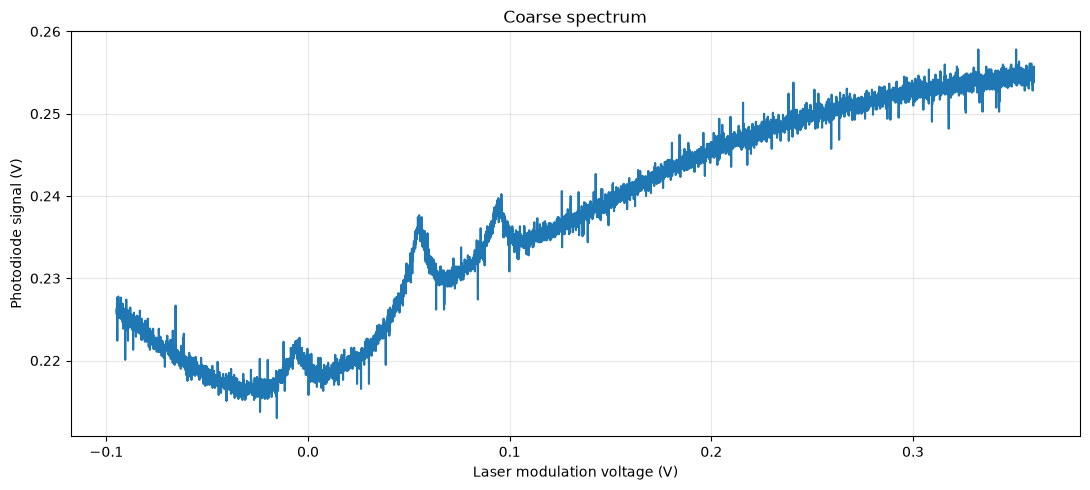

Drive holding +0.0000 V


In [14]:
# ============================================================
# 3. COARSE SCAN
# ============================================================

COARSE_START_V = -0.10
COARSE_STOP_V = +0.40
COARSE_SCAN_TIME_S = 1.0
COARSE_PAUSE_S = 0.05

# Drop any leftover IQ/PID from a previous lock attempt so they
# do not sum onto OUT1 during the sweep.
silence_feedback(rp)

coarse_x, coarse_pd, coarse_plan, coarse_full = drive.quick_scan(
    start_v=COARSE_START_V,
    stop_v=COARSE_STOP_V,
    scan_time=COARSE_SCAN_TIME_S,
    pause_s=COARSE_PAUSE_S,
)

plt.figure(figsize=(11, 5))
plt.plot(coarse_x, coarse_pd)
plt.xlabel("Laser modulation voltage (V)")
plt.ylabel("Photodiode signal (V)")
plt.title("Coarse spectrum")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Drive holding {drive.current_v:+.4f} V")


In [15]:
# Peak finding lives in laserlock.peaks.
# PEAK_CHOICE is 1-based, left to right in the Doppler well:
#   1 = small left,  2 = middle,  3 = tallest right


The Doppler envelope is subtracted with a wide smoother so the three sub-Doppler lines remain in the residual. Those three are labeled **1, 2, 3 from left to right**. `PEAK_CHOICE` selects which one to use. If a coarse scan does not show all three, it is repeated.


Triplet (left to right):
  1: V = -0.006056 V, prominence = 0.00501412
  2: V = +0.055026 V, prominence = 0.00984586
  3: V = +0.094125 V, prominence = 0.00513804  <-- selected

Coarse target (peak 3): +0.094125 V


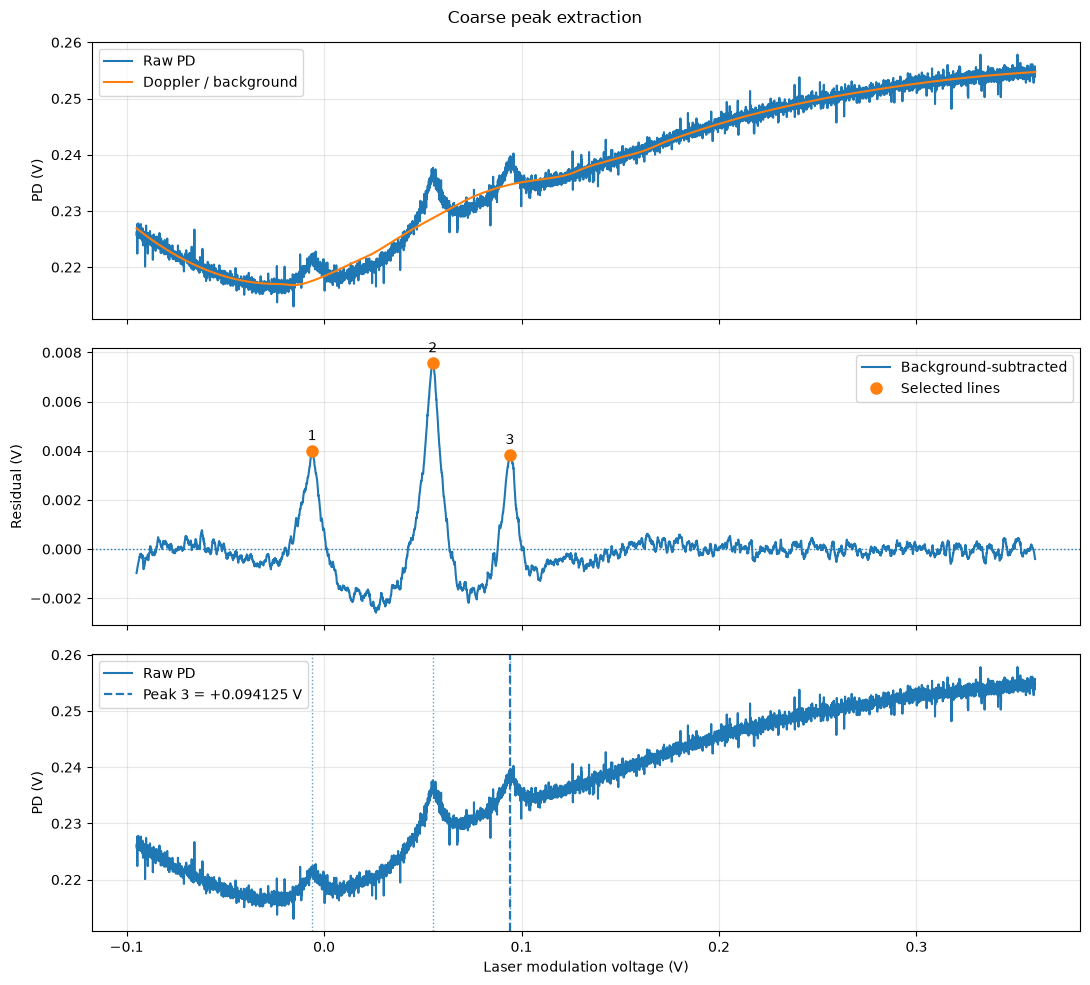

In [16]:
# ============================================================
# 5. COARSE PEAK IDENTIFICATION
# ============================================================

PEAK_CHOICE = 3          # 1=left small, 2=middle, 3=right tallest
MAX_COARSE_RETRIES = 4   # extra coarse scans if the triplet is missing

CLUSTER_WINDOW_V = 0.08
REL_PROMINENCE = 0.12

coarse_analysis = None
for attempt in range(1, MAX_COARSE_RETRIES + 1):
    if attempt > 1:
        print(f"Attempt {attempt}: three peaks not found. Rescanning.")
        coarse_x, coarse_pd, coarse_plan, coarse_full = drive.quick_scan(
            start_v=COARSE_START_V,
            stop_v=COARSE_STOP_V,
            scan_time=COARSE_SCAN_TIME_S,
            pause_s=COARSE_PAUSE_S,
        )
    coarse_analysis = analyze_spectrum(
        coarse_x,
        coarse_pd,
        peak_choice=PEAK_CHOICE,
        cluster_window_v=CLUSTER_WINDOW_V,
        rel_prominence=REL_PROMINENCE,
    )
    if coarse_analysis["ok"]:
        break
else:
    plot_peak_analysis(coarse_x, coarse_pd, coarse_analysis, title="Coarse — triplet not found")
    raise RuntimeError(
        "Coarse scan did not show three sub-Doppler peaks. "
        "Check alignment / PEAK_CHOICE settings."
    )

print("Triplet (left to right):")
for p in coarse_analysis["triplet"]:
    mark = "  <-- selected" if p is coarse_analysis["target"] else ""
    print(
        f"  {p['label']}: V = {p['voltage']:+.6f} V, "
        f"prominence = {p['prominence']:.6g}{mark}"
    )

coarse_target_v = coarse_analysis["target"]["voltage"]
print(f"\nCoarse target (peak {PEAK_CHOICE}): {coarse_target_v:+.6f} V")

plot_peak_analysis(coarse_x, coarse_pd, coarse_analysis, title="Coarse peak extraction")


## Error sweep and lock point

Park uphill of the tallest coarse line, turn on the dither, and take a **fast analog ramp** (about 0.5 s — the same speed class as the coarse scan). Scope records IN1 and iq0 together.

The lock voltage is then the Linien simple-autolock point on that finished trace: mid-height between min and max of the first S-curve from the high-V end. DC-park immediately and close I.

A 20 s software staircase shears the spectrum because the laser drifts during the walk. A 0.5 s FPGA ramp does not.


In [17]:
# ============================================================
# 6. DITHER + DOWNHILL ERROR SWEEP (RECORD ONLY)
# ============================================================

DITHER_FREQUENCY_HZ = 20_000.0
DITHER_AMPLITUDE_V = 0.002
IQ_BANDWIDTH_HZ = 2_000.0
IQ_ACBANDWIDTH_HZ = 1_000.0
LOCKIN_PHASE_DEG = 0.0
QUADRATURE_FACTOR = 10

APPROACH_MARGIN_V = 0.10
APPROACH_EXTRA_V = 0.060
ERROR_SCAN_TIME_S = 0.5   # analog ramp, same speed class as the coarse scan

PID_P = 0.0
PID_I_HZ = 1.0
PID_CORR_MIN_V = -0.20
PID_CORR_MAX_V = +0.20
LOCK_MONITOR_S = 3.0

if PEAK_CHOICE != 3:
    print(
        f"Note: PEAK_CHOICE={PEAK_CHOICE}, but the downhill window is built "
        "for the tallest/rightmost line (peak 3). Using that line anyway."
    )

v3 = coarse_analysis["triplet"][-1]["voltage"]
print(f"Tallest coarse peak V3 = {v3:+.6f} V")

silence_feedback(rp)
iq, pid = configure_dither(
    rp,
    frequency_hz=DITHER_FREQUENCY_HZ,
    amplitude_v=DITHER_AMPLITUDE_V,
    bandwidth_hz=IQ_BANDWIDTH_HZ,
    acbandwidth_hz=IQ_ACBANDWIDTH_HZ,
    phase_deg=LOCKIN_PHASE_DEG,
    quadrature_factor=QUADRATURE_FACTOR,
    pid_corr_min_v=PID_CORR_MIN_V,
    pid_corr_max_v=PID_CORR_MAX_V,
)
time.sleep(0.2)

sweep = record_dithered_sweep(
    drive,
    rp,
    v_peak=v3,
    margin_v=APPROACH_MARGIN_V,
    extra_v=APPROACH_EXTRA_V,
    scan_time=ERROR_SCAN_TIME_S,
    lock_min_v=LOCK_MIN_V,
    lock_max_v=LOCK_MAX_V,
)


Tallest coarse peak V3 = +0.094125 V
Dither on, PID open.
  0.0020 V @ 20000.0 Hz, phase 0.0 deg

Coarse tallest peak: +0.094125 V

------------------------------------------------------------
FAST ERROR SCAN (analog ramp, record IN1 + iq0)
------------------------------------------------------------
Holding +0.1941 V
Scan:      +0.194125 -> +0.034125 V
Scan time: 0.500 s
Window:    1.074 s  (decimation 8192)
Scan samples: 7172
Now holding:  +0.034125 V
PD ptp 0.0291 V,  |error| max 0.0073 V


First S-curve window samples 1766..3118
min @ +0.12821 V,  max @ +0.15548 V
LOCK POINT +0.142999 V  (mid-height +0.0001 V)


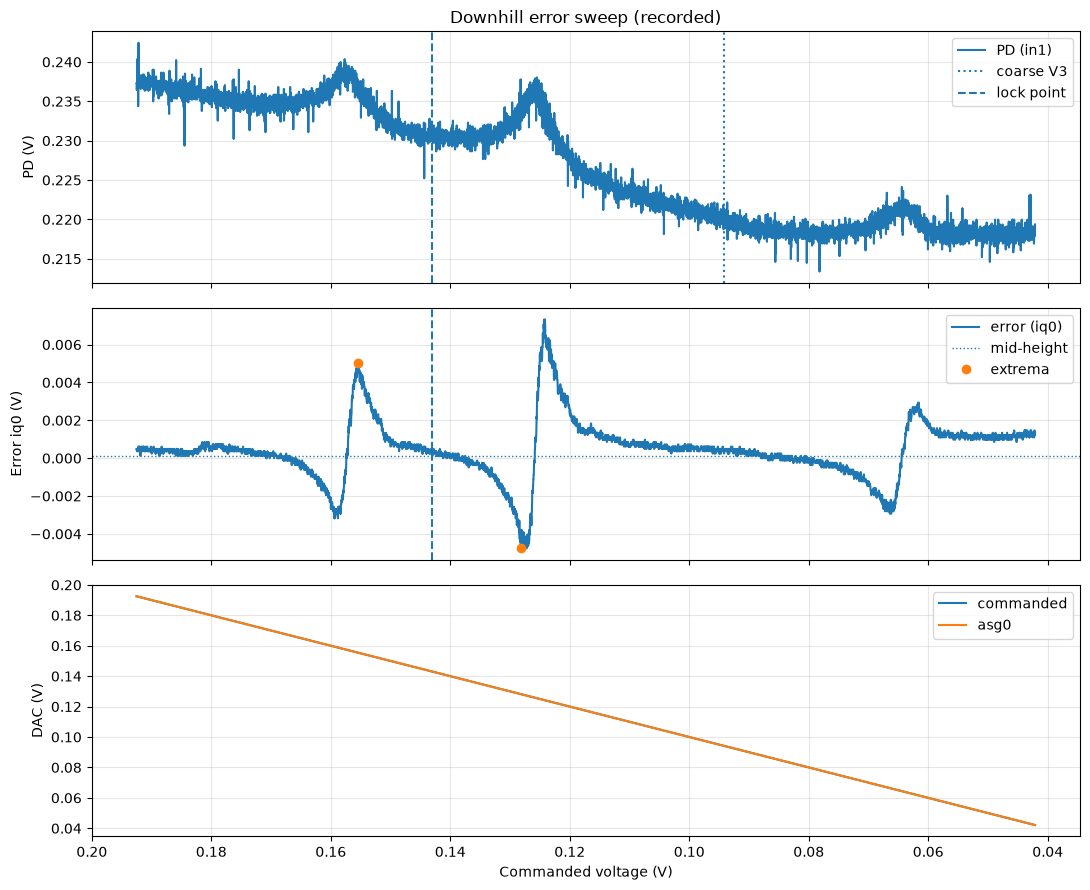

Holding +0.1430 V
Lock point +0.142999 V  (error mid-height +0.0001 V, dE/dV rising)
Slope rises with voltage: if the PID runs away, add 180 deg to IQ phase (or use a negative I).


In [18]:
# ============================================================
# 7. LOCK POINT FROM THE FINISHED TRACE + PARK
# ============================================================

lp = lock_point_from_trace(sweep["voltage"], sweep["error"])
lock_voltage = lp["lock_voltage"]
print(
    f"First S-curve window samples {lp['i0']}..{lp['i1']}"
)
print(
    f"min @ {sweep['voltage'][lp['min_idx']]:+.5f} V,  "
    f"max @ {sweep['voltage'][lp['max_idx']]:+.5f} V"
)
print(
    f"LOCK POINT {lock_voltage:+.6f} V  (mid-height {lp['mean_error']:+.4f} V)"
)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
v, e, pd = sweep["voltage"], sweep["error"], sweep["pd"]
axes[0].plot(v, pd, label="PD (in1)")
axes[0].axvline(v3, linestyle=":", label="coarse V3")
axes[0].axvline(lock_voltage, linestyle="--", label="lock point")
axes[0].set_ylabel("PD (V)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Downhill error sweep (recorded)")

axes[1].plot(v, e, label="error (iq0)")
axes[1].axhline(lp["mean_error"], linestyle=":", linewidth=1, label="mid-height")
axes[1].axvline(lock_voltage, linestyle="--")
axes[1].plot(
    [v[lp["min_idx"]], v[lp["max_idx"]]],
    [e[lp["min_idx"]], e[lp["max_idx"]]],
    "o",
    label="extrema",
)
axes[1].set_ylabel("Error iq0 (V)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(v, v, label="commanded")
axes[2].plot(v, sweep["asg"], label="asg0")
axes[2].set_xlabel("Commanded voltage (V)")
axes[2].set_ylabel("DAC (V)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)
for ax in axes:
    ax.invert_xaxis()
plt.tight_layout()
plt.show()

lp = park_at_lock_point(drive, sweep)
lock_voltage = lp["lock_voltage"]


## Close the PID

ASG is parked at the recorded lock point. IQ is already dithering. Close **I-only**. If it runs away, `disengage_lock(drive, rp)` and add 180° to `LOCKIN_PHASE_DEG`, then re-run the sweep cell.


In [19]:
print(f"Parked at {drive.current_v:+.6f} V")
print(f"AUTO_LOCK = {AUTO_LOCK},  PID I = {PID_I_HZ} Hz,  P = {PID_P}")
print("Call disengage_lock(drive, rp) to drop IQ/PID and return to 0 V.")


Parked at +0.142999 V
AUTO_LOCK = True,  PID I = 1.0 Hz,  P = 0.0
Call disengage_lock(drive, rp) to drop IQ/PID and return to 0 V.


In [20]:
# ============================================================
# 8. OPTIONAL HOLD-POINT DIAGNOSTIC
# ============================================================

# diagnose_hold_points(
#     drive,
#     rp,
#     voltages=[0.0, v3 + APPROACH_MARGIN_V, v3, v3 - 0.03],
# )
print("Optional: diagnose_hold_points(drive, rp, [0.0, v3 + APPROACH_MARGIN_V, v3])")


Optional: diagnose_hold_points(drive, rp, [0.0, v3 + APPROACH_MARGIN_V, v3])


In [21]:
# ============================================================
# 9. ENGAGE
# ============================================================

if AUTO_LOCK:
    engage_i_lock(
        rp,
        i_gain_hz=PID_I_HZ,
        p_gain=PID_P,
        monitor_s=LOCK_MONITOR_S,
        rail_v=PID_CORR_MAX_V,
    )
else:
    print("AUTO_LOCK=False: parked at the lock point with dither on.")
    print("Run engage_i_lock(rp, i_gain_hz=PID_I_HZ) when ready.")


Closing PID loop (integral only)...
PID engaged.  P=0.0  I=1.0005159917010866 Hz
If it runs away: disengage_lock(); set IQ phase += 180; retry the approach.
Monitoring for 3.0 s...
  t=0.5s  ival=-0.0048 V  error=+0.0027 V  PD=+0.2381 V  asg0=+0.1430 V
  t=1.0s  ival=-0.0070 V  error=+0.0011 V  PD=+0.2389 V  asg0=+0.1430 V
  t=1.5s  ival=-0.0094 V  error=-0.0006 V  PD=+0.2386 V  asg0=+0.1430 V
  t=2.0s  ival=-0.0076 V  error=-0.0014 V  PD=+0.2386 V  asg0=+0.1430 V
  t=2.5s  ival=-0.0061 V  error=-0.0013 V  PD=+0.2384 V  asg0=+0.1430 V
  t=3.0s  ival=-0.0037 V  error=+0.0003 V  PD=+0.2381 V  asg0=+0.1430 V
PID correction stayed inside the rails.


In [22]:
# ============================================================
# 11. SHUTDOWN
# ============================================================
#
#drive.shutdown()
#
# Slews to 0 V, then disconnects OUT1. Run this when the experiment is done.

print(f"Laser drive holding {drive.current_v:+.6f} V. Call drive.shutdown() to finish.")


Laser drive holding +0.142999 V. Call drive.shutdown() to finish.
